In [1]:
import polars as pl

data = pl.read_csv("llm-march2026-alfabank/train_dataset.tsv", separator="\t")
data_synth = pl.read_csv("synthetic.csv")
# data = pl.concat([data, data_synth])
data.head(5), data.shape

(shape: (5, 3)
 ┌─────────────────────────────────┬──────────────────────────┬─────────────────────────────────┐
 │ text                            ┆ target                   ┆ entity                          │
 │ ---                             ┆ ---                      ┆ ---                             │
 │ str                             ┆ str                      ┆ str                             │
 ╞═════════════════════════════════╪══════════════════════════╪═════════════════════════════════╡
 │ Вы можете обновить client secr… ┆ []                       ┆ empty                           │
 │ Возможно, произошел временный … ┆ []                       ┆ empty                           │
 │ Наши запросы с API ключом bk_a… ┆ [(26, 69, 'API ключи')]  ┆ ['bk_api_key_ABCDEF1234567890A… │
 │ Сгенерируйте новый JWT для сер… ┆ []                       ┆ empty                           │
 │ Возможно, токен 6363069502:y-3… ┆ [(16, 100, 'API ключи')] ┆ ['6363069502:y-3-y-6-z-0-w-5-w… │
 └───

In [2]:
# Извлекаем метки из target средствами Polars
# target содержит строки вида "[(26, 69, 'API ключи')]" — извлекаем только названия меток
labels = (
    data
    .filter(pl.col("target") != "[]")
    .select(
        pl.col("target")
        .str.extract_all(r"'([^']+)'")
        .explode()
        .alias("label")
    )
)

# Распределение меток
label_counts = (
    labels
    .group_by("label")
    .len()
    .sort("len", descending=True)
)

print(f"Всего уникальных меток: {label_counts.shape[0]}\n")
print("Распределение меток:")
print(label_counts)

# Строки без меток
empty_count = data.filter(pl.col("target") == "[]").shape[0]
print(f"\nСтрок без меток: {empty_count} из {data.shape[0]} ({empty_count/data.shape[0]*100:.1f}%)")


Всего уникальных меток: 30

Распределение меток:
shape: (30, 2)
┌─────────────────────────────────┬─────┐
│ label                           ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ 'Полный адрес'                  ┆ 811 │
│ 'Дата рождения'                 ┆ 362 │
│ 'API ключи'                     ┆ 337 │
│ 'Гражданство и названия стран'  ┆ 333 │
│ 'Место рождения'                ┆ 324 │
│ …                               ┆ …   │
│ 'Одноразовые коды'              ┆ 139 │
│ 'Свидетельство о рождении'      ┆ 138 │
│ 'СНИЛС клиента'                 ┆ 133 │
│ 'Email'                         ┆ 129 │
│ 'Серия и номер вида на жительс… ┆ 104 │
└─────────────────────────────────┴─────┘

Строк без меток: 2586 из 8287 (31.2%)


In [3]:
import re

# Маппинг метка -> int (strip кавычек, т.к. extract_all возвращает полный матч)
unique_labels = sorted(lb.strip("'") for lb in label_counts["label"].to_list())
label2id = {label: i for i, label in enumerate(unique_labels)}

pattern = re.compile(r"\((\d+),\s*(\d+),\s*'([^']+)'\)")

data = data.with_columns(
    pl.col("target").map_elements(
        lambda s: [[int(a), int(b), label2id[c]] for a, b, c in pattern.findall(s)],
        return_dtype=pl.List(pl.List(pl.Int64))
    ).alias("target")
)

print(data.select("text", "target").head(10))

shape: (10, 2)
┌─────────────────────────────────┬─────────────────┐
│ text                            ┆ target          │
│ ---                             ┆ ---             │
│ str                             ┆ list[list[i64]] │
╞═════════════════════════════════╪═════════════════╡
│ Вы можете обновить client secr… ┆ []              │
│ Возможно, произошел временный … ┆ []              │
│ Наши запросы с API ключом bk_a… ┆ [[26, 69, 0]]   │
│ Сгенерируйте новый JWT для сер… ┆ []              │
│ Возможно, токен 6363069502:y-3… ┆ [[16, 100, 0]]  │
│ Мне нужен API ключ для интегра… ┆ []              │
│ Пожалуйста, попробуйте переген… ┆ []              │
│ Наш внутренний бот перестал от… ┆ [[44, 90, 0]]   │
│ Убедитесь, что для Google Clou… ┆ [[40, 122, 0]]  │
│ Я не могу получить выписку по … ┆ [[57, 81, 0]]   │
└─────────────────────────────────┴─────────────────┘


In [4]:
id2label = {v: k for k, v in label2id.items()}

label_dist = (
    data.select(pl.col("target").explode().alias("span"))
    .filter(pl.col("span").is_not_null())
    .select(pl.col("span").list.get(2).alias("label_id"))
    .group_by("label_id")
    .len()
    .sort("len", descending=True)
    .with_columns(pl.col("label_id").replace_strict(id2label).alias("label"))
    .select("label_id", "label", "len")
)

print(f"Уникальных меток: {label_dist.shape[0]}")
print(f"Строк без меток: {data['target'].is_null().sum()}\n")
print(label_dist)


Уникальных меток: 30
Строк без меток: 0

shape: (30, 3)
┌──────────┬─────────────────────────────────┬─────┐
│ label_id ┆ label                           ┆ len │
│ ---      ┆ ---                             ┆ --- │
│ i64      ┆ str                             ┆ u32 │
╞══════════╪═════════════════════════════════╪═════╡
│ 22       ┆ Полный адрес                    ┆ 811 │
│ 10       ┆ Дата рождения                   ┆ 362 │
│ 0        ┆ API ключи                       ┆ 337 │
│ 5        ┆ Гражданство и названия стран    ┆ 333 │
│ 13       ┆ Место рождения                  ┆ 324 │
│ …        ┆ …                               ┆ …   │
│ 18       ┆ Одноразовые коды                ┆ 139 │
│ 26       ┆ Свидетельство о рождении        ┆ 138 │
│ 24       ┆ СНИЛС клиента                   ┆ 133 │
│ 2        ┆ Email                           ┆ 129 │
│ 27       ┆ Серия и номер вида на жительст… ┆ 104 │
└──────────┴─────────────────────────────────┴─────┘


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "DeepPavlov/distilrubert-base-cased-conversational"
MAX_LENGTH  = 512
BATCH_SIZE  = 64
EPOCHS      = 10
LR          = 5e-5

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# ── BIO label set ────────────────────────────────────────────────────────────
bio_labels   = ["O"] + [f"{p}-{lbl}" for lbl in unique_labels for p in ("B", "I")]
bio_label2id = {lb: i for i, lb in enumerate(bio_labels)}
num_ner_labels = len(bio_labels)

print(f"device: {DEVICE} | NER labels: {num_ner_labels}")


# ── Dataset ──────────────────────────────────────────────────────────────────
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts   = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx], self.targets[idx]


# ── Collate ──────────────────────────────────────────────────────────────────
def collate_fn(batch, tokenizer):
    texts, targets = zip(*batch)

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )
    offset_mappings = encoded.pop("offset_mapping")

    token_labels_batch, binary_labels_batch = [], []
    for spans, offsets in zip(targets, offset_mappings):
        binary_labels_batch.append(1 if spans else 0)
        token_labels = []
        for tok_start, tok_end in offsets.tolist():
            if tok_start == tok_end:
                token_labels.append(-100)
                continue
            label = bio_label2id["O"]
            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    name  = unique_labels[label_id]
                    label = bio_label2id[f"B-{name}" if tok_start <= span_start else f"I-{name}"]
                    break
            token_labels.append(label)
        token_labels_batch.append(token_labels)

    encoded["labels"]        = torch.tensor(token_labels_batch,  dtype=torch.long)
    encoded["binary_labels"] = torch.tensor(binary_labels_batch, dtype=torch.long)
    return encoded


# ── Model ─────────────────────────────────────────────────────────────────────
class MultiTaskNER(nn.Module):
    def __init__(self, model_name, num_ner_labels):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.ner_head = nn.Linear(h, num_ner_labels)
        self.cls_head = nn.Linear(h, 2)

    def forward(self, input_ids, attention_mask, labels=None, binary_labels=None, **kwargs):
        hidden     = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        ner_logits = self.ner_head(hidden)       # (B, T, num_ner_labels)
        cls_logits = self.cls_head(hidden[:, 0]) # (B, 2)

        loss = None
        if labels is not None:
            cls_loss = nn.CrossEntropyLoss(ignore_index=-100)(cls_logits, binary_labels)

            pos_mask = binary_labels == 1
            if pos_mask.any():
                ner_loss = nn.CrossEntropyLoss(ignore_index=-100)(
                    ner_logits[pos_mask].reshape(-1, num_ner_labels),
                    labels[pos_mask].reshape(-1),
                )
                loss = cls_loss + ner_loss
            else:
                loss = cls_loss

        return {"loss": loss, "ner_logits": ner_logits, "cls_logits": cls_logits}


device: cuda | NER labels: 61


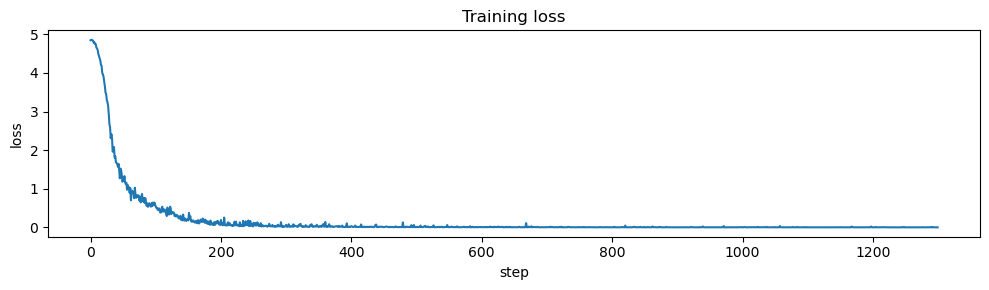

In [8]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

PLOT_EVERY = 50

# ── Data & training ───────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset   = NERDataset(data["text"].to_list(), data["target"].to_list())
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

model     = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)

loss_history = []

def plot_loss(loss_history):
    clear_output(wait=True)
    plt.figure(figsize=(10, 3))
    plt.plot(loss_history)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.show()

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        loss  = model(**batch)["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        total_loss += loss.item()

        if (step + 1) % PLOT_EVERY == 0:
            plot_loss(loss_history)
            print(f"Epoch {epoch+1}/{EPOCHS} | step {step+1}/{len(dataloader)} | loss {loss.item():.4f}")

    print(f"── Epoch {epoch+1}/{EPOCHS} avg loss: {total_loss / len(dataloader):.4f}")

plot_loss(loss_history)


In [10]:
torch.save(model.state_dict(), "model.pth")

In [11]:
model.load_state_dict(torch.load("model.pth"))

/tmp/ipykernel_388105/1722216506.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pth"))


<All keys matched successfully>

In [12]:
df = pl.read_csv("llm-march2026-alfabank/private_test_dataset.csv")
df.head(5), df.shape

(shape: (5, 2)
 ┌─────┬─────────────────────────────────┐
 │ id  ┆ text                            │
 │ --- ┆ ---                             │
 │ i64 ┆ str                             │
 ╞═════╪═════════════════════════════════╡
 │ 0   ┆ Банкомат не запрашивает CVV-ко… │
 │ 1   ┆ Уточните, пожалуйста, ФИО полу… │
 │ 2   ┆ Проверьте папку «Спам» в вашей… │
 │ 3   ┆ Я пытаюсь обновить данные в ли… │
 │ 4   ┆ Хочу подключить СМС-информиров… │
 └─────┴─────────────────────────────────┘,
 (3552, 2))

In [13]:
model.eval()


def decode_triplets(pred_ids, offsets, attention_mask):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue

        tag = bio_labels[int(pred_id)]
        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets


@torch.no_grad()
def predict_triplets(texts, batch_size=64):
    all_triplets = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
            return_offsets_mapping=True,
        )

        offset_mapping = encoded.pop("offset_mapping")
        attention_mask = encoded["attention_mask"]
        batch = {k: v.to(DEVICE) for k, v in encoded.items()}

        outputs = model(**batch)
        ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()
        cls_pred_ids = outputs["cls_logits"].argmax(dim=-1).cpu()

        for has_entity, pred_ids, offsets, mask in zip(
            cls_pred_ids.tolist(),
            ner_pred_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask.tolist(),
        ):
            if has_entity == 0:
                all_triplets.append([])
                continue

            all_triplets.append(decode_triplets(pred_ids, offsets, mask))

    return all_triplets


pred_triplets = predict_triplets(df["text"].to_list())

# offset_mapping уже даёт символьные индексы токенов в исходной строке,
# поэтому для ответа берём первый start и последний end у непрерывного BIO-спана.
def format_prediction(triplets):
    if not triplets:
        return '[]'
    parts = [f"({int(s)}, {int(e)}, '{l}')" for s, e, l in triplets]
    return f'[{", ".join(parts)}]'


formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)

In [14]:
submission_df.drop("text").write_csv("predictions.csv")
submission_df.head(10)

id,text,Prediction
i64,str,str
0,"""Банкомат не запрашивает CVV-ко…","""[]"""
1,"""Уточните, пожалуйста, ФИО полу…","""[(106, 124, 'Номер телефона')]"""
2,"""Проверьте папку «Спам» в вашей…","""[]"""
3,"""Я пытаюсь обновить данные в ли…","""[(88, 93, 'Паспортные данные')…"
4,"""Хочу подключить СМС-информиров…","""[(82, 94, 'Водительское удосто…"
5,"""Могу ли я закрыть счет по врем…","""[(51, 63, 'Временное удостовер…"
6,"""Проверьте, пожалуйста, нет ли …","""[]"""
7,"""Мой СНИЛС 300-400-500 05 не пр…","""[(10, 24, 'СНИЛС клиента')]"""
8,"""Я пытался расплатиться картой …","""[(57, 61, 'ПИН код')]"""


In [46]:
# def extract_entities_from_text(text, triplets):
#     return [
#         (int(start), int(end), str(label), text[int(start):int(end)])
#         for start, end, label in triplets
#     ]


# entity_examples = [
#     extract_entities_from_text(text, triplets)
#     for text, triplets in zip(df["text"].to_list(), pred_triplets)
# ]

# df_with_entities = df.select("id", "text").with_columns(
#     pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8),
#     pl.Series("predicted_entities", [str(x) for x in entity_examples], dtype=pl.Utf8)
# )

# (
#     df_with_entities
#     .filter(pl.col("Prediction") != "[]")
#     .select("id", "text", "Prediction", "predicted_entities")
#     .head(10)
# )